In [3]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
from celluloid import Camera
from scipy.integrate import solve_ivp

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


In [4]:
deg = np.pi / 180
rad = 180 / np.pi

In [9]:
def edm_pendulo_simple(t, Ys, g, L): #Ys=[theta, u]
    teta, u = Ys

    dteta_dt = u
    du_dt = - (g / L) * np.sin(teta)

    return [dteta_dt, du_dt] 

In [10]:
edm_pendulo_simple(1, [2, 3], 4, 5)

[3, np.float64(-0.7274379414605454)]

In [117]:
ts = np.linspace(0, 10, 100)
Y0s = [120 * deg, 0]
g = 9.8 #m/s^2
L = 1. #m

sol = solve_ivp(
    edm_pendulo_simple, 
    [ts[0], ts[-1]], 
    Y0s, 
    t_eval=ts, 
    args=(g, L))

In [118]:
#Variables de configuración 
teta = sol.y[0]
u = sol.y[1]

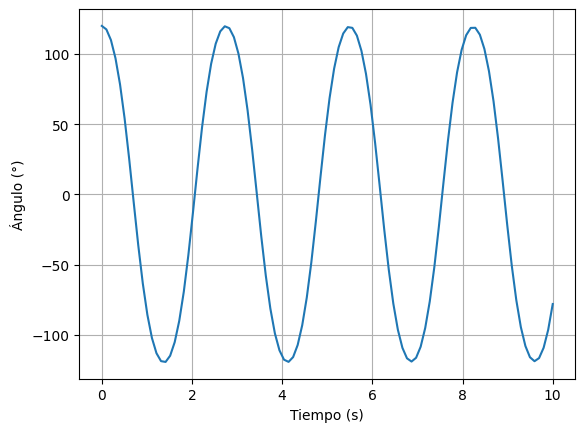

In [119]:
plt.plot(ts, teta * rad)
plt.xlabel('Tiempo (s)')
plt.ylabel('Ángulo (°)')
plt.grid()
plt.show()

Coordenadas:

In [120]:
xs = L * np.sin(teta)
ys = - L * np.cos(teta)

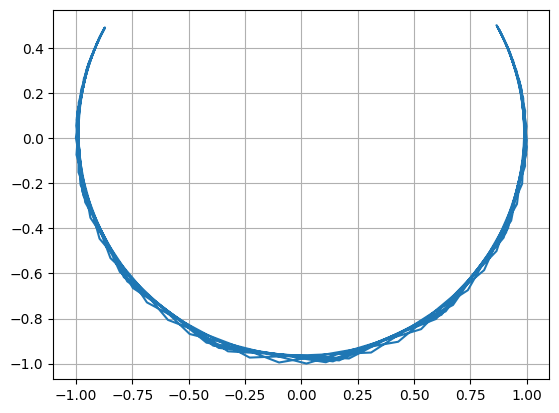

In [121]:
plt.plot(xs, ys)
plt.axis('equal')
plt.grid()
plt.show()

Animación

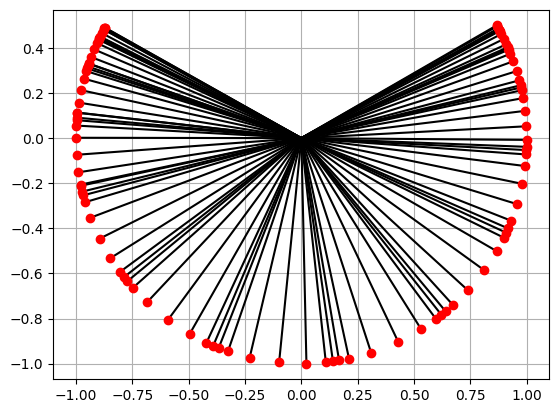

In [122]:
fig = plt.figure()
camera = Camera(fig)

for i, t in enumerate(ts):
    plt.plot([0, xs[i]], [0, ys[i]], 'k-')
    plt.plot(xs[i], ys[i], 'ro')
    camera.snap()
plt.axis('equal')
plt.grid()


In [123]:
from IPython.display import HTML
anim = camera.animate()
HTML(anim.to_jshtml())